# Project: Penguin Species Analysis using Seaborn

## Problem Statement
- Perform Exploratory Data Analysis (EDA) and create beautiful, insightful visualization using **Seaborn**.
- visualization should be able to find difference between three pengiun species (Adelie, Chinstrap, Gentoo) based on their physical charecteristics and habitat.

In [528]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

## Dataset
- Using the Penguins dataset
- it can be loaded using **load_dataset** of seaborn module

In [529]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Data preparation

In [530]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [531]:
# best to drop the null value rows like above shown 
# if we try to handle the vsualization may be diffcult or improper
df = df.dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## Core Visualization

#### Species Distribution

In [532]:
fig1, ax1 = plt.subplots(1,2,figsize=[13,5])

C:\Users\user\AppData\Local\Temp\ipykernel_3692\334626772.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  b = sns.countplot(data=df,x='species',palette='Set1',edgecolor='black',ax=ax1[0])


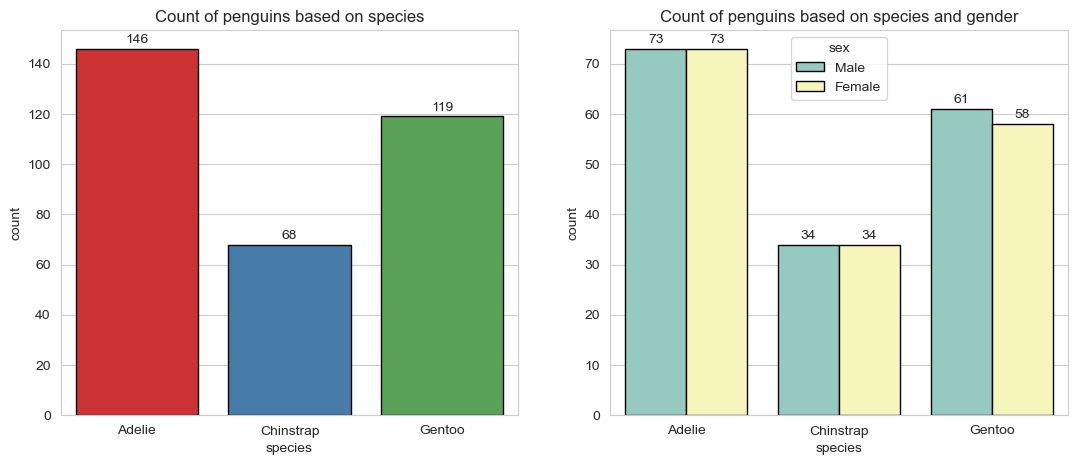

In [533]:
b = sns.countplot(data=df,x='species',palette='Set1',edgecolor='black',ax=ax1[0])
ax1[0].set_title('Count of penguins based on species')
for container2 in b.containers:
   b.bar_label(container2, fmt='%d', label_type='edge', padding=2)
    
a = sns.countplot(data=df,x='species',hue='sex',palette='Set3',edgecolor='black',ax=ax1[1])
ax1[1].set_title('Count of penguins based on species and gender')
for container1 in a.containers:
   a.bar_label(container1, fmt='%d', label_type='edge', padding=2)

plt.show()
fig1.savefig("Species_distribution.png", dpi=300)

- INSIGHTS:
  1. there are totally **333** penguins
  2. there are three species **Adelie, Chinstrap, Gentoo**
  3. species wise total penguins
     - **Adelie** - 146
       - Male - 73
       - Female - 73
     - **Chinstrap** - 68
       - Male - 34
       - Female - 34
     - **Gentoo** - 119
        - Male - 61
        - Female - 58

#### Bill length vs Bill depth

In [534]:
fig2, ax2 = plt.subplots(1,2,figsize=[13,5])

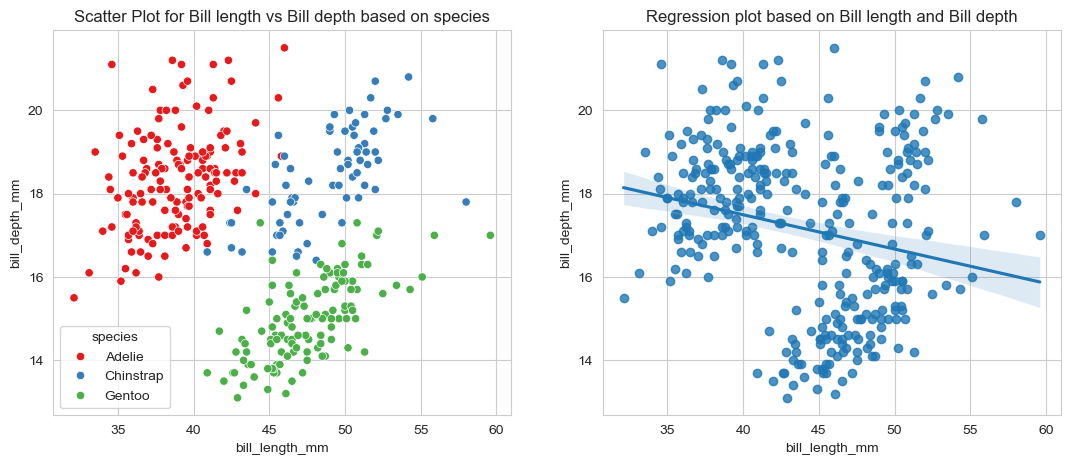

In [535]:
c = sns.scatterplot(data=df,x='bill_length_mm',y='bill_depth_mm',hue='species',palette='Set1',ax=ax2[0])
d = sns.regplot(data=df,x='bill_length_mm',y='bill_depth_mm',ax=ax2[1])
ax2[0].set_title('Scatter Plot for Bill length vs Bill depth based on species')
ax2[1].set_title('Regression plot based on Bill length and Bill depth')
plt.show()
fig2.savefig("bill_length_bill_depth.png", dpi=300)

- INSIGHTS:
  1. **Adelie:**
     - bill_length range is 32 - 47 mm 
     - bill_depth range is 15 - 21 mm
  2. **Chinstrap:**
     - bill_length range is 40 - 58 mm 
     - bill_depth range is 16 - 21 mm
  3. **Gentoo:**
     - bill_length range is 40 - 60 mm 
     - bill_depth range is 12 - 18 mm

#### Flipper length distribution

In [536]:
fig3, ax3 = plt.subplots(1,3,figsize=[14,4])

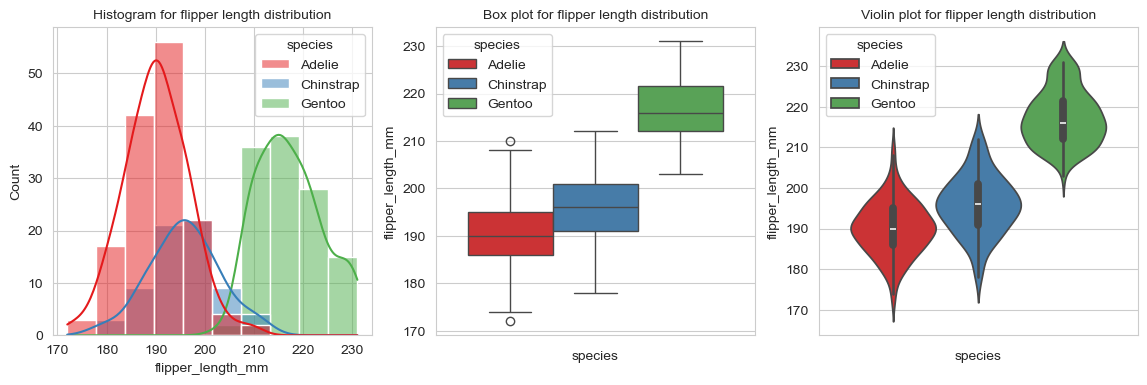

In [537]:
e = sns.histplot(data=df,x='flipper_length_mm',kde=True,hue='species',palette='Set1',ax=ax3[0])
ax3[0].set_title('Histogram for flipper length distribution',fontsize=10)

f = sns.boxplot(data=df,y='flipper_length_mm',hue='species',ax=ax3[1],palette='Set1')
ax3[1].set_title('Box plot for flipper length distribution',fontsize=10)
ax3[1].set_xlabel('species')

g = sns.violinplot(data=df,y='flipper_length_mm',hue='species',ax=ax3[2],palette='Set1')
ax3[2].set_title('Violin plot for flipper length distribution',fontsize=10)
ax3[2].set_xlabel('species')

plt.show()
fig3.savefig("Flipper_length_distribution.png", dpi=300)

- INSIGHTS:
  - above visualizations show clear description of the species about penguins

#### Body Mass by Species and Sex

In [538]:
# Adelie species average body weight calculation based on sex
body_a = df[df['species']=='Adelie']
a_male = body_a[body_a['sex']=='Male']
a_female = body_a[body_a['sex']=='Female']
a_avg = body_a['body_mass_g'].mean()
a_male_avg = a_male['body_mass_g'].mean()
a_female_avg = a_female['body_mass_g'].mean()

body_c = df[df['species']=='Chinstrap']
c_male = body_c[body_c['sex']=='Male']
c_female = body_c[body_c['sex']=='Female']
c_avg = body_c['body_mass_g'].mean()
c_male_avg = c_male['body_mass_g'].mean()
c_female_avg = c_female['body_mass_g'].mean()


body_g = df[df['species']=='Gentoo']
g_male = body_g[body_g['sex']=='Male']
g_female = body_g[body_g['sex']=='Female']
g_avg = body_g['body_mass_g'].mean()
g_male_avg = g_male['body_mass_g'].mean()
g_female_avg = g_female['body_mass_g'].mean()

In [539]:
fig4, ax4 = plt.subplots(1,2,figsize=[13,5])

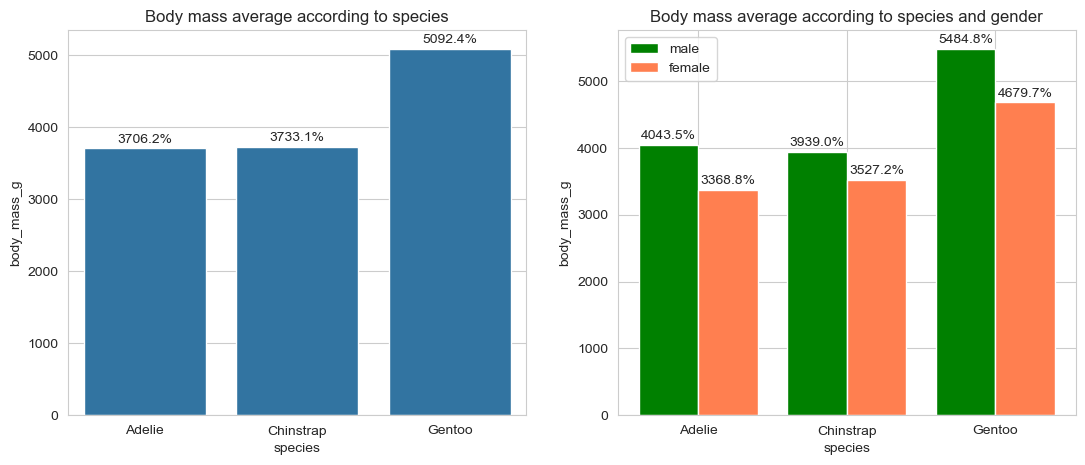

In [540]:
xpos2 = np.arange(len(df.species.unique()))
h = sns.barplot(data=[a_avg,c_avg,g_avg],ax=ax4[0])
ax4[0].set_title('Body mass average according to species')
ax4[0].set_xlabel('species')
ax4[0].set_ylabel('body_mass_g')
ax4[0].set_xticks(xpos2,df.species.unique())
for container2 in h.containers:
   h.bar_label(container2, fmt='%0.1f%%', label_type='edge', padding=2)

xpos3 = np.arange(len(df.species.unique()))
ax4[1].bar(xpos3-0.2,[a_male_avg,c_male_avg,g_male_avg],color='green',label='male',width=0.4)
ax4[1].bar(xpos3+0.2,[a_female_avg,c_female_avg,g_female_avg],color='coral',label='female',width=0.4)
ax4[1].set_title('Body mass average according to species and gender')
ax4[1].set_xlabel('species')
ax4[1].set_ylabel('body_mass_g')
ax4[1].set_xticks(xpos3,df.species.unique())
ax4[1].legend()
for container2 in ax4[1].containers:
   ax4[1].bar_label(container2, fmt='%0.1f%%', label_type='edge', padding=2)

plt.show()
fig4.savefig("Body_mass.png", dpi=300)

- INSIGHTS:
  1. Body mass average according to species:
     - **Adelie** - 3706.2
       - male - 4043.5
       - fenale - 3368.8
     - **Chinstap** - 3733.1
       - male - 3939.0
       - female - 3527.2
     -  **Gentoo** - 5092.4
        - male -5484.8
        - female - 4679.7

#### Pairwise relationship

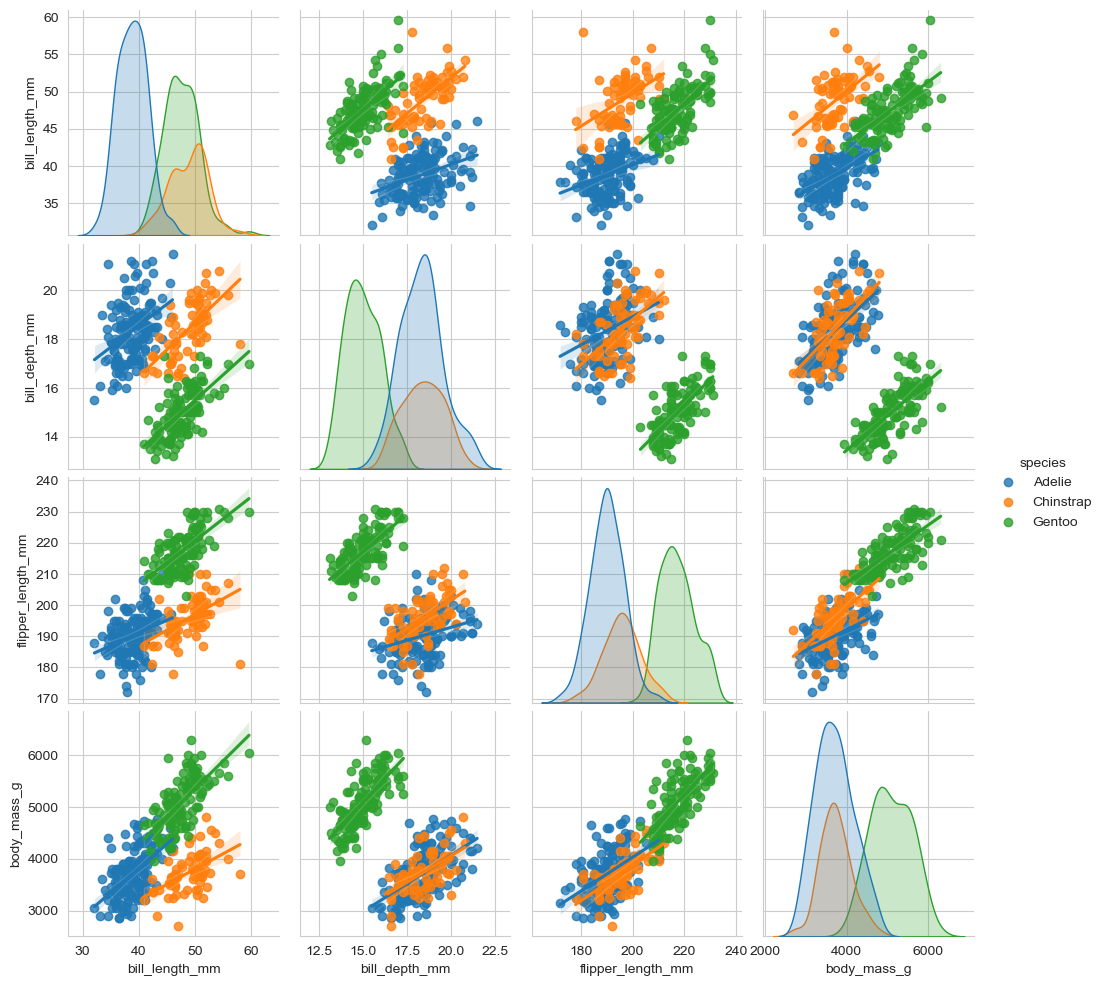

In [541]:
# pair plot for every numerical column in dataframe
i = sns.pairplot(data=df,hue='species',kind='reg')
plt.show()
i.savefig("pairwise_relationship.png", dpi=300)

- INSIGHT:
  - above pairplot shows the realtionship between every possible combination for:
    1. bill_length_mm
    2. bill_depth_mm
    3. flipper_length_mm
    4. body_mass_g

#### Correlation heatmap

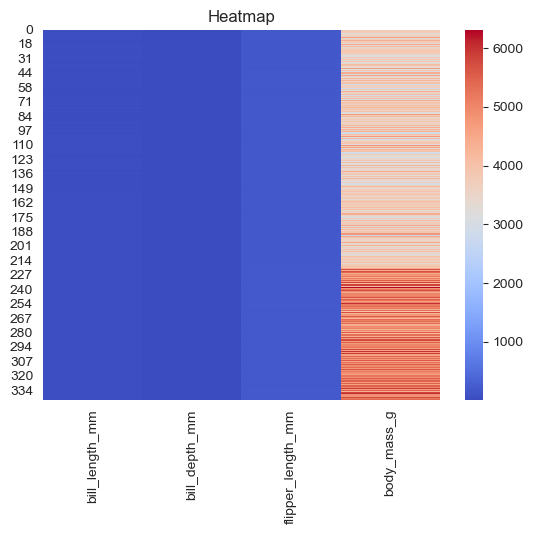

In [542]:
plt.figure()
j = sns.heatmap(data=df.drop(columns=['sex','island','species']),cmap='coolwarm')
plt.title('Heatmap')
plt.savefig("Heatmap.png", dpi=300)
plt.show()

## Conclusion

1. Identified three distinct penguin species: Adelie, Chinstrap, and Gentoo.
2. Gentoo penguins were found to have the highest average body mass and flipper length.
3. Adelie penguins generally exhibited smaller body measurements compared to the other species.
4. A strong positive correlation was observed between body mass and flipper length.
5. Species distribution varied across different islands, indicating habitat preferences.
6. Visualizations such as scatter plots, pair plots, and heatmaps helped uncover relationships among variables.
7. Overall, the EDA provided meaningful insights into penguin characteristics and established a strong foundation for further statistical or machine learning analysis.